In [1]:
import keras
import tensorflow as tf

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)

Keras: 3.15.1
TensorFlow: 2.21.0


In [2]:
print(tf.config.list_physical_devices("GPU"))

[]


In [3]:
import tensorflow as tf
x = tf.constant([10,20,30,40]) ### 1 D dimension tensor
print(x)
print("shape:", x.shape)
print("data type", x.dtype)

tf.Tensor([10 20 30 40], shape=(4,), dtype=int32)
shape: (4,)
data type <dtype: 'int32'>


In [4]:
### tensor for 2D
y = tf.constant([
    [10, 20, 30],
    [40, 50, 60]
])
print("shape", y.shape)
print("dimension", len(y.shape))

shape (2, 3)
dimension 2


In [5]:
from tensorflow import keras
layers = keras.layers.Dense(3)  ### 3 denotes the neurons , dense layer (hidden layer)
print(layers)

<Dense name=dense, built=False>


In [6]:
x = tf.constant([[1.0, 2.0, 3.0]])
output = layers(x)
print("input shape:", x.shape)
print("output shape:", output.shape)
print("output", output)

input shape: (1, 3)
output shape: (1, 3)
output tf.Tensor([[-0.8609569  4.128107   1.3442883]], shape=(1, 3), dtype=float32)


In [7]:
### activation function
## activation fn introduce non linearity , allowing neural network to learn complicated pattern
# ReLu activation fn negative number --- 0 and positive --- same positive number
import tensorflow as tf
import numpy as np
x = tf.constant([-3.0,-2.0,0,2,3])
relu_output = tf.nn.relu(x)
print("input", x.numpy())
print("ReLu", relu_output.numpy())

input [-3. -2.  0.  2.  3.]
ReLu [0. 0. 0. 2. 3.]


In [8]:
### basic model
from tensorflow import keras
model = keras.Sequential([
     keras.Input(shape=(3,)),
    keras.layers.Dense(16, activation="relu"), ### first hidden layer with 16 neuron with the activation fn of relu which converts negative valuee to zero and positive value with no changes
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid") ### final output layer with activation fn as sigmoid fn , the sigmoid converts the output 0-1 which is useful for binary classification
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam", ### it is used for updating the model weight
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
print("model compiled")


model compiled


In [10]:
import numpy as np
### now i am taking some example's of physiological feature too see model's output
## the physiological features are [heart_rate, temperature, respiratory_rate]
X_train = np.array([
     [72, 36.5, 16],
    [80, 36.8, 18],
    [90, 37.2, 20],
    [110, 38.5, 25],
    [120, 39.0, 28],
    [105, 38.2, 24]
], dtype=np.float32)
### 0 denotes less risk and 1 denotes high risk
y_train = np.array([
    0,0,0,1,1,1
], dtype=np.float32)
print("X shape:", X_train.shape)
print("y shape:", y_train.shape)


X shape: (6, 3)
y shape: (6,)


In [11]:
### training
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    verbose = 1  ### verbose is the level of output displayed during training and validation or it is used to see how much output i want to see duringg training
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step - accuracy: 0.5000 - loss: 2.7268
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 1.7526
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.9047
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6052
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.8717
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 1.1186
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 1.1980
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 1.1350
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.9769
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.7799
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.6191
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.5709


In [12]:
X_test = tf.constant([
    [1.5, 2.5, 3.5],
    [4.5, 5.5, 6.5],
    [7.5, 8.5, 9.5]
], dtype=tf.float32)

y_test = tf.constant([
    [0],
    [1],
    [1]
], dtype=tf.float32)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (3, 3)
y_test shape: (3, 1)


In [13]:
### evaluating the model
loss,accuracy = model.evaluate(
    X_test,
    y_test,
    verbose = 1
)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6667 - loss: 0.4057
Test Loss: 0.4057128131389618
Test Accuracy: 0.6666666865348816


In [14]:
### prediction
prediction = model.predict(X_test)
print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: [[0.6290971]
 [0.840646 ]
 [0.9495767]]


In [15]:
predicted_classes = (prediction >= 0.5).astype(int)

print("Predicted classes:")
print(predicted_classes)

Predicted classes:
[[1]
 [1]
 [1]]


In [16]:
print("Actual classes:")
print(y_test.numpy())

print("Predicted classes:")
print(predicted_classes)

Actual classes:
[[0.]
 [1.]
 [1.]]
Predicted classes:
[[1]
 [1]
 [1]]


In [17]:
### now creating a dummy dataset for validation
X_val = tf.constant([
    [2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0]
], dtype=tf.float32)
y_val = tf.constant([
      [0],
    [1]
], dtype=tf.float32)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (2, 3)
y_val shape: (2, 1)


In [18]:
## training with validation data
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_data = (X_val, y_val),
    verbose = 1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6667 - loss: 0.4450 - val_accuracy: 0.5000 - val_loss: 0.6261
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6667 - loss: 0.4804 - val_accuracy: 0.5000 - val_loss: 0.6279
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 0.5010 - val_accuracy: 0.5000 - val_loss: 0.6286
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5000 - loss: 0.4969 - val_accuracy: 0.5000 - val_loss: 0.6283
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6667 - loss: 0.4712 - val_accuracy: 0.5000 - val_loss: 0.6273
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8333 - loss: 0.4344 - val_accuracy: 0.5000 - val_loss: 0.6258
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8333 - loss: 0.4008 - val_accuracy: 0.5000 - val_loss: 0.6240
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.3826 - val_accuracy: 0.5000 - val_loss: 0.622

In [19]:
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


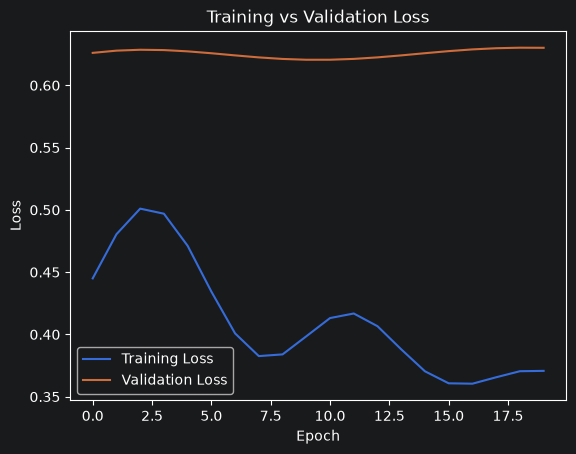

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

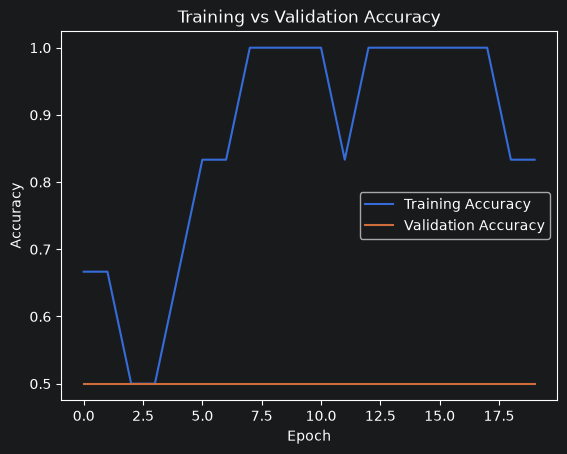

In [21]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [22]:
early_stop = keras.callbacks.EarlyStopping( ### Automatically stops training when validation performance stops improvings
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(  ###Automatically saves the best model during training
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks created")

Callbacks created


In [23]:
### retraining
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_data = (X_val,y_val),
    callbacks = [early_stop, checkpoint],
    verbose =1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8333 - loss: 0.3653 - val_accuracy: 0.5000 - val_loss: 0.6296
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 1.0000 - loss: 0.3562 - val_accuracy: 0.5000 - val_loss: 0.6288
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.3469 - val_accuracy: 0.5000 - val_loss: 0.6279
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 0.3408 - val_accuracy: 0.5000 - val_loss: 0.6270
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.3389 - val_accuracy: 0.5000 - val_loss: 0.6263
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.3400 - val_accuracy: 0.5000 - val_loss: 0.6259
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.3411 - val_accuracy: 0.5000 - val_loss: 0.6258
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.3399 - val_accuracy: 0.5000 - val_loss: 

In [24]:
### check model saved
import os
print("model saved :", os.path.exists("best_model.keras"))

model saved : True


In [25]:
### testing on the new sample
import numpy as np
new_patient = np.array([
    [0.7,0.8,0.9]
], dtype=np.float32)

prediction = model.predict(new_patient)
print("prediction:", prediction)
print(" predicted class:", (prediction >=0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
prediction: [[0.5643795]]
 predicted class: [[1]]


In [26]:
from tensorflow import keras
loaded_model = keras.models.load_model("best_model.keras")
prediction = loaded_model.predict(new_patient)
print("Prediction probability:", prediction)
print("Predicted class:", (prediction >= 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction probability: [[0.5643795]]
Predicted class: [[1]]
